# HGSEL Advanced Benchmarking Analysis

**Date:** February 14, 2026  
**Purpose:** Analyze production-readiness of HGSEL via three critical benchmarks

## Benchmarks Overview

1. **Trace-Driven Working-Set Modeling** — Is expert routing predictable?
2. **Tail-Latency Decomposition** — Can we guarantee SLOs?
3. **Expert Interference** — Is multi-tenancy safe?

Each benchmark tests a hypothesis and provides actionable metrics for Phase 4+ optimization.

## Setup and Imports

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

# Resolve repo root whether notebook is opened from repo root or notebooks/
cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "hgsel-moe"]
repo_root = next(
    (
        p for p in candidates
        if (p / "experiments").exists() and (p / "hgsel").exists()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError(f"Could not locate repo root from cwd={cwd}")

results_dir = repo_root / "results" / "notebook"
results_dir.mkdir(parents=True, exist_ok=True)

def run_benchmark(script_rel, *args):
    cmd = [sys.executable, script_rel, *map(str, args)]
    print("$", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(repo_root), capture_output=True, text=True)
    if proc.stdout:
        print(proc.stdout)
    if proc.stderr:
        print(proc.stderr)
    proc.check_returncode()
    return proc

def load_json(path):
    path = Path(path)
    if not path.is_absolute():
        path = repo_root / path
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

print("[OK] Setup complete")
print(f"  Repo root: {repo_root}")
print(f"  PyTorch version: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")


[OK] Setup complete
  Repo root: C:\dev\projects\214\hgsel-moe
  PyTorch version: 2.10.0+cpu
  CUDA available: False


## 1. Trace-Driven Working-Set Modeling

**Hypothesis:** Expert working sets are predictable and grow sublinearly with context length.

**Falsification:** Working sets are random (CV > 0.30) → caching won't help.

**Metric:** Coefficient of Variation (CV) = std / mean

In [2]:
# Notebook execution config (CLI-driven smoke runs by default)
device = "cuda" if torch.cuda.is_available() else "cpu"
smoke = True
no_plot = True

workset_json = Path("results/notebook/workset_smoke.json")
tail_json = Path("results/notebook/tail_latency_smoke.json")
interference_json = Path("results/notebook/interference_smoke.json")

print(f"device={device}")
print(f"smoke={smoke}, no_plot={no_plot}")
print(f"workset_json={workset_json}")
print(f"tail_json={tail_json}")
print(f"interference_json={interference_json}")


device=cpu
smoke=True, no_plot=True
workset_json=results\notebook\workset_smoke.json
tail_json=results\notebook\tail_latency_smoke.json
interference_json=results\notebook\interference_smoke.json


In [3]:
# Run trace-driven workset benchmark via script CLI
workset_args = []
if smoke:
    workset_args.append("--smoke")
workset_args += ["--device", device, "--json-output", workset_json]
if no_plot:
    workset_args.append("--no-plot")

_ = run_benchmark("experiments/trace_driven_workset.py", *workset_args)


$ C:\Python314\python.exe experiments/trace_driven_workset.py --smoke --device cpu --json-output results\notebook\workset_smoke.json --no-plot


Trace-Driven Expert Working-Set Modeling

Device: cpu
Run config: context_lengths=[16, 32, 64], expert_configs=[32], num_tokens=128

Testing with 32 experts (k_active=2)

  Context length: 16
    Working set size: 32
    Utilization: 100.0%
    Expected (if random): 200.0% * 8 batches = 16

  Context length: 32
    Working set size: 32
    Utilization: 100.0%
    Expected (if random): 200.0% * 4 batches = 8

  Context length: 64
    Working set size: 32
    Utilization: 100.0%
    Expected (if random): 200.0% * 2 batches = 4

  Predictability Analysis:
    Mean working set: 32.0
    Std dev: 0.0
    Coefficient of variation: 0.000
    [OK] PREDICTABLE (low variation)

Generating working-set curve...
  Plot generation skipped (--no-plot)

WORKING-SET HYPOTHESIS TEST

Overall coefficient of variation: 0.000
[OK] CONCLUSION: Working sets are HIGHLY PREDICTABLE
[OK] Use case: Compile expert dispatch, pre-fetch patterns

Details:
  n_experts=32: CV=0.000
  Wrote JSON summary: results\notebo

In [4]:
# Load workset JSON output
workset_payload = load_json(workset_json)
workset_summary = workset_payload["summary"]
workset_config_results = workset_payload["config_results"]

workset_rows = []
for cfg in workset_config_results:
    for row in cfg["per_context"]:
        workset_rows.append({
            "config_name": cfg["config_name"],
            "n_experts": cfg["n_experts"],
            "context_length": row["context_length"],
            "working_set_size": row["working_set_size"],
            "utilization": row["utilization"],
        })

print("Loaded workset JSON:")
print(f"  verdict={workset_summary['verdict']} level={workset_summary['level']}")
print(f"  overall_cv={workset_summary['overall_cv']:.3f}")
print(f"  configs={len(workset_config_results)} rows={len(workset_rows)}")

workset_rows[:5]


Loaded workset JSON:
  verdict=OK level=highly_predictable
  overall_cv=0.000
  configs=1 rows=3


[{'config_name': 'n_experts=32',
  'n_experts': 32,
  'context_length': 16,
  'working_set_size': 32,
  'utilization': 1.0},
 {'config_name': 'n_experts=32',
  'n_experts': 32,
  'context_length': 32,
  'working_set_size': 32,
  'utilization': 1.0},
 {'config_name': 'n_experts=32',
  'n_experts': 32,
  'context_length': 64,
  'working_set_size': 32,
  'utilization': 1.0}]

In [5]:
# Compute / display predictability metrics from JSON
print("\n" + "="*60)
print("WORKING-SET PREDICTABILITY ANALYSIS (JSON)")
print("="*60)

for cfg in workset_config_results:
    pred = cfg.get("predictability", {})
    print(f"\n{cfg['config_name']}")
    print(f"  CV: {pred.get('cv', float('nan')):.3f}")
    print(f"  Mean working set: {pred.get('mean_working_set', float('nan')):.1f}")
    print(f"  Std dev: {pred.get('std_working_set', float('nan')):.1f}")
    print(f"  Verdict: {pred.get('verdict')} ({pred.get('level')})")

print("\nOverall:")
print(f"  verdict={workset_summary['verdict']}")
print(f"  level={workset_summary['level']}")
print(f"  overall_cv={workset_summary['overall_cv']:.3f}")



WORKING-SET PREDICTABILITY ANALYSIS (JSON)

n_experts=32
  CV: 0.000
  Mean working set: 32.0
  Std dev: 0.0
  Verdict: OK (highly_predictable)

Overall:
  verdict=OK
  level=highly_predictable
  overall_cv=0.000


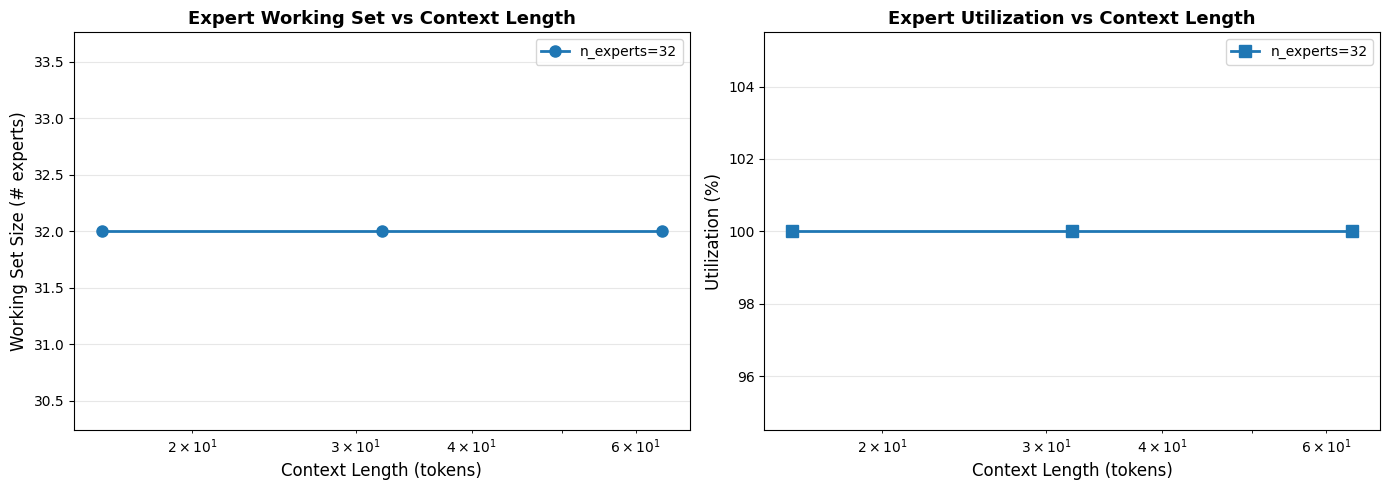


[OK] Working-set analysis complete (CV=0.000)


In [6]:
# Visualize working-set curve from JSON
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for cfg in workset_config_results:
    ctx_lens = [row["context_length"] for row in cfg["per_context"]]
    ws_sizes = [row["working_set_size"] for row in cfg["per_context"]]
    utils = [row["utilization"] * 100.0 for row in cfg["per_context"]]

    ax1.plot(ctx_lens, ws_sizes, marker="o", linewidth=2, markersize=8, label=cfg["config_name"])
    ax2.plot(ctx_lens, utils, marker="s", linewidth=2, markersize=8, label=cfg["config_name"])

ax1.set_xlabel("Context Length (tokens)", fontsize=12)
ax1.set_ylabel("Working Set Size (# experts)", fontsize=12)
ax1.set_title("Expert Working Set vs Context Length", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.set_xscale("log")
ax1.legend()

ax2.set_xlabel("Context Length (tokens)", fontsize=12)
ax2.set_ylabel("Utilization (%)", fontsize=12)
ax2.set_title("Expert Utilization vs Context Length", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.set_xscale("log")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n[OK] Working-set analysis complete (CV={workset_summary['overall_cv']:.3f})")


## 2. Tail-Latency Decomposition

**Hypothesis:** Tail latency is predictable and one component dominates.

**Falsification:** All components equal or tail is random (CV > 0.5) → need redesign.

**Metrics:** p50, p99, p999 latency (µs/token), CV

In [7]:
# Run tail-latency benchmark via script CLI and load JSON
tail_args = []
if smoke:
    tail_args.append("--smoke")
tail_args += ["--device", device, "--json-output", tail_json]
if no_plot:
    tail_args.append("--no-plot")

_ = run_benchmark("experiments/tail_latency_decomposition.py", *tail_args)
tail_payload = load_json(tail_json)
tail_summary = tail_payload["summary"]
tail_configs = tail_payload["config_results"]
tail_cfg = tail_configs[0]
tail_stats = tail_cfg["stats"]

print("\n" + "="*60)
print("TAIL-LATENCY ANALYSIS (JSON)")
print("="*60)
print(f"Overall verdict: {tail_summary['verdict']} ({tail_summary['tail_variation_level']})")
print(f"Average forward CV: {tail_summary['avg_forward_cv']:.3f}")
print(f"Selected config: {tail_cfg['config_name']}")

ordered_components = [
    "forward_pass",
    "routing_trace",
    "expert_compute_trace",
    "combine_trace",
    "dispatch_planning_trace",
    "hgsel_trace_total",
    "residual_non_hgsel",
]
for component in ordered_components:
    if component not in tail_stats:
        continue
    s = tail_stats[component]
    print(f"\n{component}:")
    print(f"  p50:  {s['p50']:.2f} us/token")
    print(f"  p99:  {s['p99']:.2f} us/token")
    print(f"  p999: {s['p999']:.2f} us/token")
    print(f"  CV:   {s['cv']:.3f}")

print("\nDominant component p99:", tail_cfg.get("dominant_component_p99"))


$ C:\Python314\python.exe experiments/tail_latency_decomposition.py --smoke --device cpu --json-output results\notebook\tail_latency_smoke.json --no-plot


Tail-Latency Decomposition (per-token basis)

Device: cpu

Run config: num_runs=8, warmup_runs=2, batch_size=4, seq_len=32, configs=32:2

Configuration: 32 experts, k_active=2

Profiling forward latency...
  Profiling 8 runs (2 warmup, 6 measured)...

Latency (per-token, microseconds):
  Component                    p50        p99        p999       std        CV
  --------------------------------------------------------------------------------
  forward_pass                1856.16    1902.87    1903.40      58.99    0.032
  routing_trace                427.94     452.65     453.10      17.46    0.041
  expert_compute_trace        1389.59    1426.23    1427.12      45.35    0.033
  combine_trace                  1.75       3.02       3.07       0.49    0.244
  dispatch_planning_trace        0.00       0.00       0.00       0.00    0.000
  hgsel_trace_total           1823.75    1865.02    1865.16      58.49    0.032
  residual_non_hgsel            32.42      38.16      38.27       3.79  

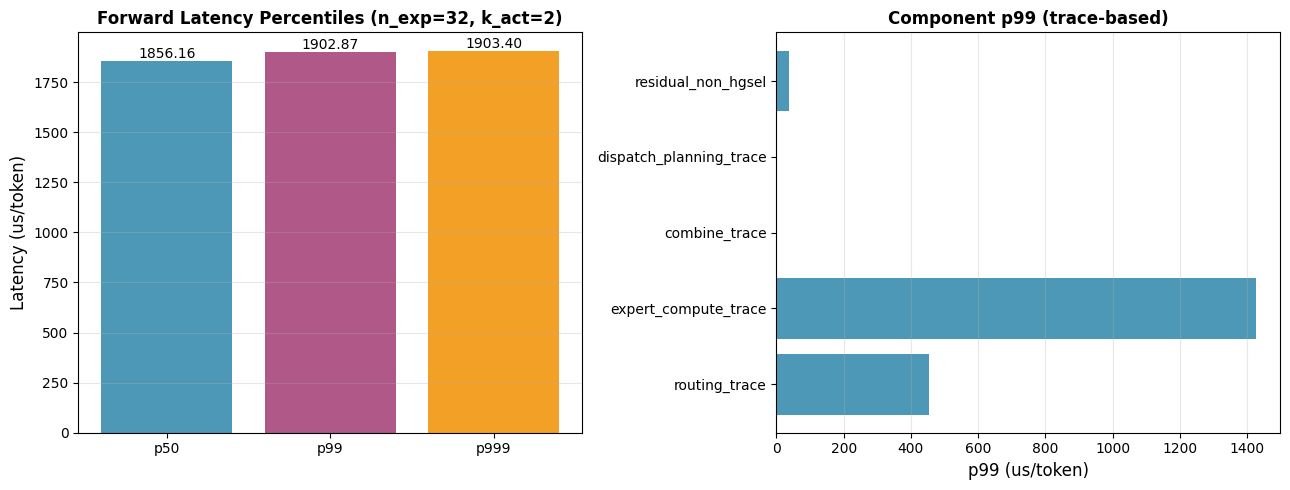


[OK] Tail-latency analysis complete


In [8]:
# Visualize latency percentiles from JSON
s = tail_cfg["forward_pass"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Forward pass percentiles
percentiles = ["p50", "p99", "p999"]
values = [s["p50"], s["p99"], s["p999"]]
colors = ["#2E86AB", "#A23B72", "#F18F01"]
bars = axes[0].bar(percentiles, values, color=colors, alpha=0.85)
axes[0].set_ylabel("Latency (us/token)", fontsize=12)
axes[0].set_title(f"Forward Latency Percentiles ({tail_cfg['config_name']})", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", ha="center", va="bottom", fontsize=10)

# Component p99 comparison (excluding aggregate buckets)
component_p99 = {
    k: v["p99"]
    for k, v in tail_stats.items()
    if k not in {"forward_pass", "hgsel_trace_total"}
}
comp_names = list(component_p99.keys())
comp_vals = [component_p99[k] for k in comp_names]
axes[1].barh(comp_names, comp_vals, color="#2E86AB", alpha=0.85)
axes[1].set_xlabel("p99 (us/token)", fontsize=12)
axes[1].set_title("Component p99 (trace-based)", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\n[OK] Tail-latency analysis complete")


## 3. Expert Interference Benchmarks

**Hypothesis:** Interference between concurrent workloads is small (< 5%).

**Falsification:** 
- No interference → isolation unnecessary
- Catastrophic (> 20%) → need strict partitioning

**Scenarios:** Isolated (baseline), Alternating (cache pressure), Random (realistic)

In [9]:
# Run expert interference benchmark via script CLI and load JSON
interference_args = []
if smoke:
    interference_args.append("--smoke")
interference_args += ["--device", device, "--json-output", interference_json]
if no_plot:
    interference_args.append("--no-plot")

_ = run_benchmark("experiments/expert_interference_benchmark.py", *interference_args)
interference_payload = load_json(interference_json)
interference_summary = interference_payload["summary"]
interference_scenarios = interference_payload["scenarios"]

print("[OK] Loaded interference JSON")
print(f"  verdict={interference_summary['verdict']} level={interference_summary['level']}")
print(f"  max_interference_abs_pct={interference_summary['max_interference_abs_pct']:.1f}%")


$ C:\Python314\python.exe experiments/expert_interference_benchmark.py --smoke --device cpu --json-output results\notebook\interference_smoke.json --no-plot


Expert Interference Benchmarks
(Coding + Math concurrent workloads)

Device: cpu
Run config: num_batches=4, batch_size=4, seq_len=32, n_experts=32, k_active=2

Creating models...

Scenario 1: ISOLATED (baseline)

  Running ISOLATED baselines...
    Workload A (coding)...
    Workload B (math)...

  Workload A: 3059.29 us/token
  Workload B: 2144.58 us/token

Scenario 2: INTERLEAVED (alternating) - L1/L2 interference

  Running INTERLEAVED (pattern=alternating)...

  Workload A:
    Latency: 2196.55 us/token
    Interference: -28.2%

  Workload B:
    Latency: 2170.12 us/token
    Interference: +1.2%

Scenario 3: INTERLEAVED (random) - Worst-case mixing

  Running INTERLEAVED (pattern=random)...

  Workload A:
    Latency: 1973.94 us/token
    Interference: -35.5%

  Workload B:
    Latency: 1898.36 us/token
    Interference: -11.5%

  Plot generation skipped (--no-plot)

EXPERT INTERFERENCE HYPOTHESIS TEST

Max interference magnitude observed: 35.5%
[FAIL] CONCLUSION: Interference is S

In [10]:
# Scenario 1: Isolated (baseline)
print("\n" + "="*60)
print("Scenario 1: ISOLATED (baseline)")
print("="*60)

isolated = interference_scenarios["isolated_baseline_mean_us"]
baseline_a = isolated["workload_a"]
baseline_b = isolated["workload_b"]

print(f"\n  Workload A (coding): {baseline_a:.2f} us/token")
print(f"  Workload B (math):   {baseline_b:.2f} us/token")



Scenario 1: ISOLATED (baseline)

  Workload A (coding): 3059.29 us/token
  Workload B (math):   2144.58 us/token


In [11]:
# Scenario 2: Alternating (L1/L2 cache interference)
print("\n" + "="*60)
print("Scenario 2: INTERLEAVED (alternating)")
print("="*60)

metrics_alt = interference_scenarios["alternating"]
print(f"\n  Workload A:")
print(f"    Latency: {metrics_alt['workload_a']['interleaved_mean_us']:.2f} us/token")
print(f"    Interference: {metrics_alt['workload_a']['interference_pct']:+.1f}%")
print(f"\n  Workload B:")
print(f"    Latency: {metrics_alt['workload_b']['interleaved_mean_us']:.2f} us/token")
print(f"    Interference: {metrics_alt['workload_b']['interference_pct']:+.1f}%")



Scenario 2: INTERLEAVED (alternating)

  Workload A:
    Latency: 2196.55 us/token
    Interference: -28.2%

  Workload B:
    Latency: 2170.12 us/token
    Interference: +1.2%


In [12]:
# Scenario 3: Random (worst-case mixing)
print("\n" + "="*60)
print("Scenario 3: INTERLEAVED (random)")
print("="*60)

metrics_rand = interference_scenarios["random"]
print(f"\n  Workload A:")
print(f"    Latency: {metrics_rand['workload_a']['interleaved_mean_us']:.2f} us/token")
print(f"    Interference: {metrics_rand['workload_a']['interference_pct']:+.1f}%")
print(f"\n  Workload B:")
print(f"    Latency: {metrics_rand['workload_b']['interleaved_mean_us']:.2f} us/token")
print(f"    Interference: {metrics_rand['workload_b']['interference_pct']:+.1f}%")



Scenario 3: INTERLEAVED (random)

  Workload A:
    Latency: 1973.94 us/token
    Interference: -35.5%

  Workload B:
    Latency: 1898.36 us/token
    Interference: -11.5%


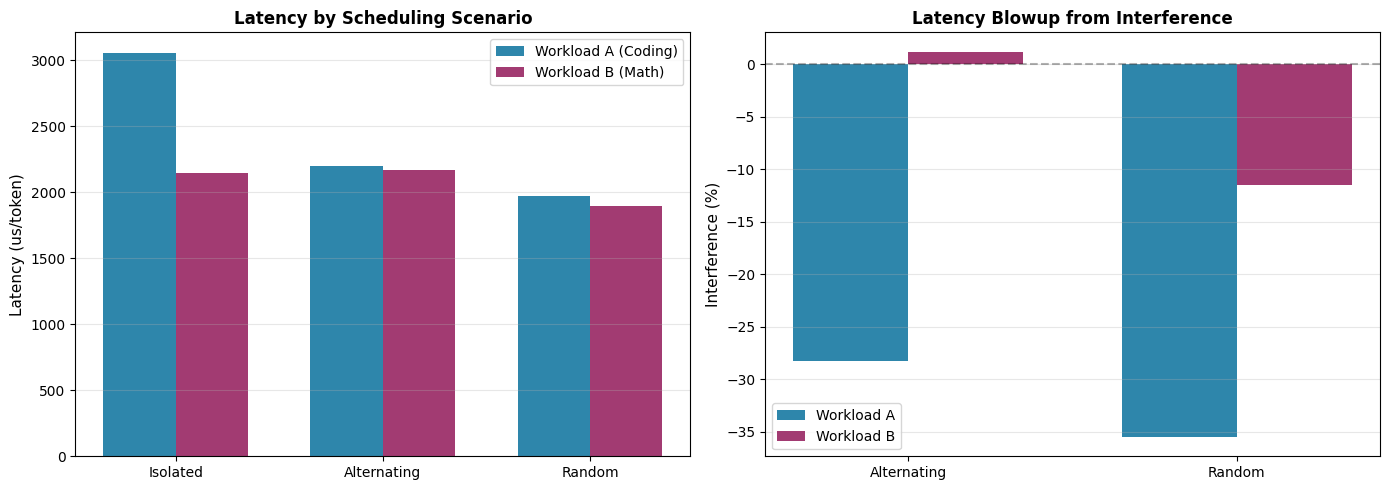

In [13]:
# Visualize interference from JSON
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency by scenario
scenarios = ["Isolated", "Alternating", "Random"]
workload_a_lats = [
    baseline_a,
    metrics_alt["workload_a"]["interleaved_mean_us"],
    metrics_rand["workload_a"]["interleaved_mean_us"],
]
workload_b_lats = [
    baseline_b,
    metrics_alt["workload_b"]["interleaved_mean_us"],
    metrics_rand["workload_b"]["interleaved_mean_us"],
]

x = np.arange(len(scenarios))
width = 0.35
axes[0].bar(x - width/2, workload_a_lats, width, label="Workload A (Coding)", color="#2E86AB")
axes[0].bar(x + width/2, workload_b_lats, width, label="Workload B (Math)", color="#A23B72")
axes[0].set_ylabel("Latency (us/token)", fontsize=11)
axes[0].set_title("Latency by Scheduling Scenario", fontsize=12, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Interference %
scenarios_interf = ["Alternating", "Random"]
interf_a = [
    metrics_alt["workload_a"]["interference_pct"],
    metrics_rand["workload_a"]["interference_pct"],
]
interf_b = [
    metrics_alt["workload_b"]["interference_pct"],
    metrics_rand["workload_b"]["interference_pct"],
]
x2 = np.arange(len(scenarios_interf))
axes[1].bar(x2 - width/2, interf_a, width, label="Workload A", color="#2E86AB")
axes[1].bar(x2 + width/2, interf_b, width, label="Workload B", color="#A23B72")
axes[1].axhline(y=0, color="k", linestyle="--", alpha=0.3)
axes[1].set_ylabel("Interference (%)", fontsize=11)
axes[1].set_title("Latency Blowup from Interference", fontsize=12, fontweight="bold")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(scenarios_interf)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [14]:
# Summary verdict from JSON
print("\n" + "="*60)
print("EXPERT INTERFERENCE VERDICT")
print("="*60)
print(f"\nMax interference observed: {interference_summary['max_interference_abs_pct']:.1f}%")
print(f"\n[{interference_summary['verdict']}] CONCLUSION: {interference_summary['message']}")
print(f"[{interference_summary['verdict']}] Implication: {interference_summary['implication']}")
print("\n[OK] Interference analysis complete")



EXPERT INTERFERENCE VERDICT

Max interference observed: 35.5%

[FAIL] CONCLUSION: Interference is SEVERE
[FAIL] Implication: Need strict resource partitioning or isolation

[OK] Interference analysis complete


## Summary and Recommendations

### Decision Matrix

Based on the three benchmarks, determine next steps:

| Benchmark | Metric | Verdict | Next Action |
|-----------|--------|---------|-------------|
| **Working Set** | CV < 0.15 | Predictable | ✓ Compile routing, prefetch experts |
| | CV 0.15-0.30 | Moderate | ~ Adaptive caching |
| | CV > 0.30 | Unpredictable | ✗ Dynamic dispatch only |
| **Tail Latency** | CV < 0.2 | Predictable | ✓ Guarantee SLOs, co-schedule |
| | CV 0.2-0.5 | Moderate | ~ Timeout-based scheduling |
| | CV > 0.5 | Unpredictable | ✗ Architecture redesign |
| **Interference** | < 5% | Negligible | ✓ Multi-tenancy safe |
| | 5-20% | Moderate | ~ Soft partitioning |
| | > 20% | Severe | ✗ Strict isolation |

### Phase 4+ Roadmap

If benchmarks pass:
1. **Routing compiler** (predictable working sets)
2. **Expert prefetching** (small working sets)
3. **SLO enforcement** (predictable tail latency)
4. **Multi-tenant scheduler** (low interference)

If benchmarks fail:
1. **Root-cause analysis** (hash quality? CUDA overhead?)
2. **Architecture tuning** (expert count, k_active)
3. **Algorithm optimization** (dispatch, combine overhead)

---

**See Also:**
- [ADVANCED_BENCHMARKS.md](../ADVANCED_BENCHMARKS.md) — Detailed interpretation guide
- [HGSEL_BUILD_PLAN.md](../HGSEL_BUILD_PLAN.md) — Phase roadmap
- [README.md](../README.md) — Project overview